# 🌱 AI Food Waste Prediction System

### Sustainable Development Goal : Responsible Consumption and Production

A machine learning-based project that predicts **total food waste in tons** using food, economic, population, and household-related factors.

**Model:** Random Forest Regressor  
**Dataset:** Worldwide Food Waste Dataset  
**Platform:** Google Colab  
**Interface:** Gradio

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import kagglehub

# Download the latest version
path = kagglehub.dataset_download("aritra100/worldwide-food-waste-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'worldwide-food-waste-dataset' dataset.
Path to dataset files: /kaggle/input/worldwide-food-waste-dataset


In [42]:
import os

print(os.listdir(path))

['WorldWide_foodwastage_dataset.csv']


In [43]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "WorldWide_foodwastage_dataset.csv"))

df.head()

,Country,Year,Food Types,Total Waste in Tons,Food Economic Loss (Million $),Avg Waste per Capita (Kg),Country Population (Million) (Not Accurate),Household Waste (%)
0,Australia,2019,Fruits & Vegetables,19268.63,18686.68,72.69,87.59,53.64
1,Indonesia,2019,Prepared Food,3916.97,4394.48,192.52,1153.99,30.61
2,Germany,2022,Dairy Products,9700.16,8909.16,166.94,1006.11,48.08
3,France,2023,Fruits & Vegetables,46299.69,40551.22,120.19,953.05,31.91
4,France,2023,Beverages,33096.57,36980.82,104.74,1105.47,36.06


In [44]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (5000, 8)

Columns:
['Country', 'Year', 'Food Types', 'Total Waste in Tons', 'Food Economic Loss (Million $)', 'Avg Waste per Capita (Kg)', 'Country Population (Million) (Not Accurate)', 'Household Waste (%)']


In [45]:
df.isnull().sum()

,0
Country,0
Year,0
Food Types,0
Total Waste in Tons,0
Food Economic Loss (Million $),0
Avg Waste per Capita (Kg),0
Country Population (Million) (Not Accurate),0
Household Waste (%),0


In [46]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Country                                      5000 non-null   object 
 1   Year                                         5000 non-null   int64  
 2   Food Types                                   5000 non-null   object 
 3   Total Waste in Tons                          5000 non-null   float64
 4   Food Economic Loss (Million $)               5000 non-null   float64
 5   Avg Waste per Capita (Kg)                    5000 non-null   float64
 6   Country Population (Million) (Not Accurate)  5000 non-null   float64
 7   Household Waste (%)                          5000 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 312.6+ KB


In [48]:
df.head()

,Country,Year,Food Types,Total Waste in Tons,Food Economic Loss (Million $),Avg Waste per Capita (Kg),Country Population (Million) (Not Accurate),Household Waste (%)
0,Australia,2019,Fruits & Vegetables,19268.63,18686.68,72.69,87.59,53.64
1,Indonesia,2019,Prepared Food,3916.97,4394.48,192.52,1153.99,30.61
2,Germany,2022,Dairy Products,9700.16,8909.16,166.94,1006.11,48.08
3,France,2023,Fruits & Vegetables,46299.69,40551.22,120.19,953.05,31.91
4,France,2023,Beverages,33096.57,36980.82,104.74,1105.47,36.06


In [49]:
df["Total Waste in Tons"].describe()

,Total Waste in Tons
count,5000.000000
mean,25061.780072
std,14245.119588
min,502.610000
25%,12783.737500
50%,24865.220000
75%,37471.035000
max,49990.760000


In [50]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [51]:
df.groupby("Food Types")["Total Waste in Tons"].mean().sort_values(ascending=False)

,Total Waste in Tons
Food Types,
Beverages,25593.826745
Meat & Seafood,25407.185983
Frozen Food,25243.481577
Prepared Food,25217.043488
Fruits & Vegetables,25035.614839
Dairy Products,24824.946964
Bakery Items,24742.786524
Grains & Cereals,24367.856895


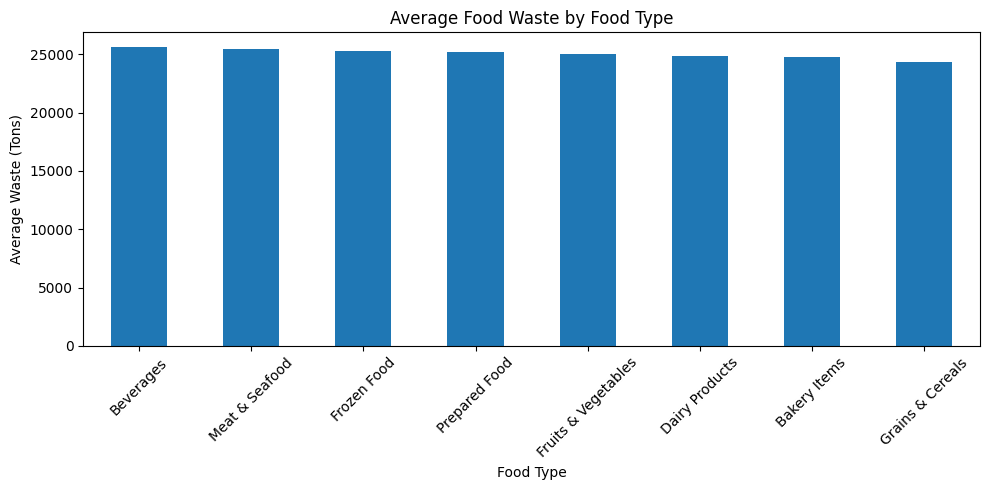

In [52]:
plt.figure(figsize=(10, 5))

food_waste = df.groupby("Food Types")["Total Waste in Tons"].mean().sort_values(ascending=False)

food_waste.plot(kind="bar")

plt.title("Average Food Waste by Food Type")
plt.xlabel("Food Type")
plt.ylabel("Average Waste (Tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

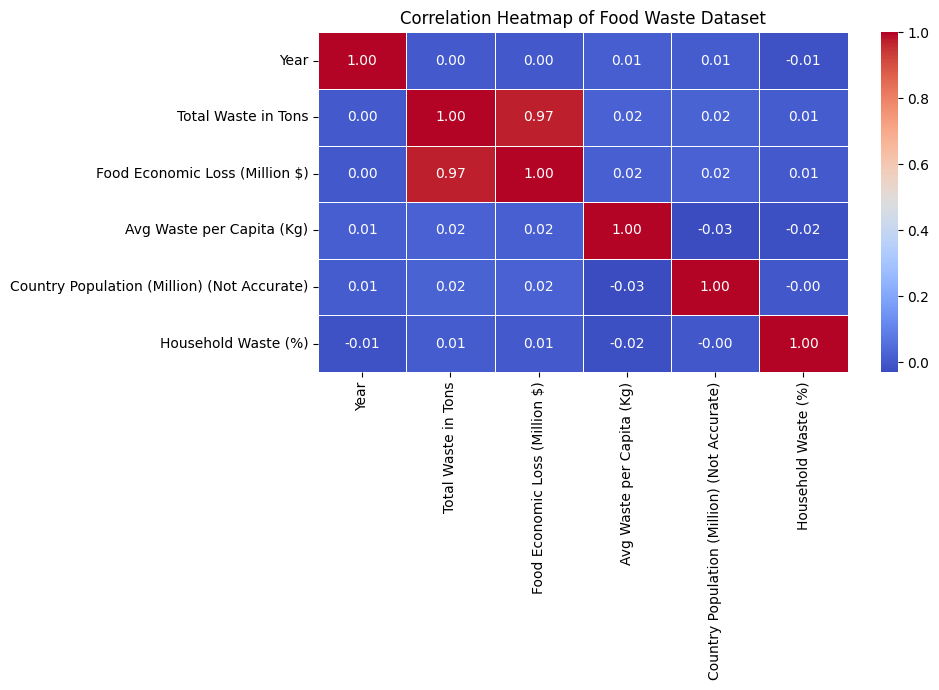

In [53]:
plt.figure(figsize=(10, 7))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Food Waste Dataset")
plt.tight_layout()
plt.show()

In [54]:
X = df.drop("Total Waste in Tons", axis=1)
y = df["Total Waste in Tons"]

In [55]:
categorical_cols = ["Country", "Food Types"]

In [56]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [57]:
print("Features:", X.shape)

Features: (5000, 31)


In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 31)
y shape: (5000,)


In [59]:
X.head()

,Year,Food Economic Loss (Million $),Avg Waste per Capita (Kg),Country Population (Million) (Not Accurate),Household Waste (%),Country_Australia,Country_Brazil,Country_Canada,Country_China,Country_France,...,Country_Turkey,Country_UK,Country_USA,Food Types_Beverages,Food Types_Dairy Products,Food Types_Frozen Food,Food Types_Fruits & Vegetables,Food Types_Grains & Cereals,Food Types_Meat & Seafood,Food Types_Prepared Food
0,2019,18686.68,72.69,87.59,53.64,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2019,4394.48,192.52,1153.99,30.61,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2022,8909.16,166.94,1006.11,48.08,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2023,40551.22,120.19,953.05,31.91,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,2023,36980.82,104.74,1105.47,36.06,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 31)
Testing data: (1000, 31)


In [61]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [62]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[44571.5617 45454.026  16195.2696 23178.5638 41480.768  39448.4848
 21497.4277  7029.4464 40820.0426 37460.0942]


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
------------------
MAE : 2319.77
RMSE: 3085.51
R²  : 0.956


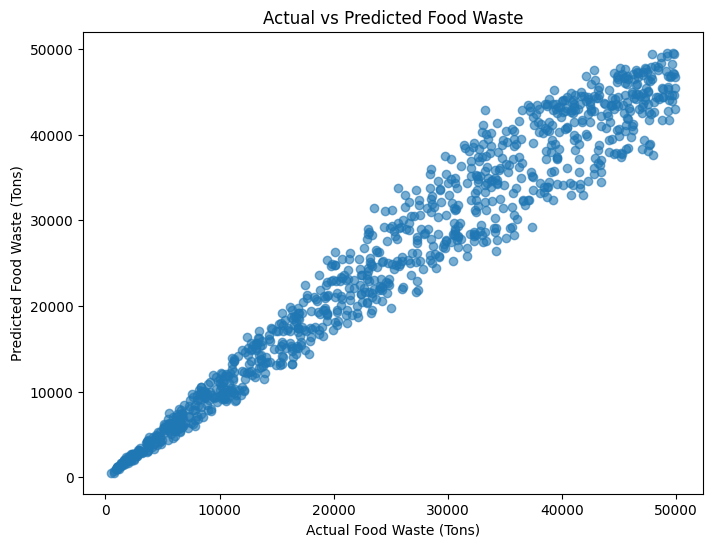

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Food Waste (Tons)")
plt.ylabel("Predicted Food Waste (Tons)")
plt.title("Actual vs Predicted Food Waste")

plt.show()

In [65]:
df.corr(numeric_only=True)["Total Waste in Tons"].sort_values(ascending=False)

,Total Waste in Tons
Total Waste in Tons,1.000000
Food Economic Loss (Million $),0.974522
Country Population (Million) (Not Accurate),0.024048
Avg Waste per Capita (Kg),0.019987
Household Waste (%),0.010367
Year,0.003452


In [66]:
import joblib

joblib.dump(model, "food_waste_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [67]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [68]:
from google.colab import files

files.download("food_waste_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
!pip -q install gradio

In [71]:
import gradio as gr
import pandas as pd
import joblib

# Load trained model
model = joblib.load("food_waste_model.pkl")
feature_names = joblib.load("feature_names.pkl")


def predict_food_waste(
    country,
    food_type,
    year,
    economic_loss,
    waste_per_capita,
    population,
    household_waste
):

    # Create basic input
    input_data = pd.DataFrame({
        "Year": [year],
        "Food Economic Loss (Million $)": [economic_loss],
        "Avg Waste per Capita (Kg)": [waste_per_capita],
        "Country Population (Million) (Not Accurate)": [population],
        "Household Waste (%)": [household_waste]
    })

    # Add all Country columns
    for col in feature_names:
        if col.startswith("Country_"):
            input_data[col] = 0

    country_col = "Country_" + country

    if country_col in input_data.columns:
        input_data[country_col] = 1

    # Add all Food Type columns
    for col in feature_names:
        if col.startswith("Food Types_"):
            input_data[col] = 0

    food_col = "Food Types_" + food_type

    if food_col in input_data.columns:
        input_data[food_col] = 1

    # Match exact training feature order
    input_data = input_data.reindex(
        columns=feature_names,
        fill_value=0
    )

    # Prediction
    prediction = model.predict(input_data)[0]

    return f"{prediction:,.2f} tons"


countries = [
    "Australia", "Brazil", "Canada", "China", "France",
    "Germany", "India", "Italy", "Japan", "Mexico",
    "Russia", "South Africa", "South Korea", "Spain",
    "Turkey", "UK", "USA"
]

food_types = [
    "Beverages",
    "Dairy Products",
    "Frozen Food",
    "Fruits & Vegetables",
    "Grains & Cereals",
    "Meat & Seafood",
    "Prepared Food",
    "Bakery Items"
]


app = gr.Interface(
    fn=predict_food_waste,
    inputs=[
        gr.Dropdown(countries, label="Country", value="India"),
        gr.Dropdown(food_types, label="Food Type", value="Fruits & Vegetables"),
        gr.Number(value=2025, label="Year"),
        gr.Number(value=10000, label="Food Economic Loss (Million $)"),
        gr.Number(value=100, label="Average Waste per Capita (Kg)"),
        gr.Number(value=100, label="Country Population (Million)"),
        gr.Number(value=30, label="Household Waste (%)")
    ],
    outputs=gr.Textbox(label="Predicted Food Waste"),
    title="AI Food Waste Prediction System",
    description="Machine Learning system for predicting total food waste in tons."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ce63837f20c81fa010.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
